<a href="https://colab.research.google.com/github/zixian0821-zoe/stochastic_search_and_optimization/blob/main/hw_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from scipy import stats
import warnings

warnings.filterwarnings('ignore')


def sa_ld50(theta0, n, gain_func, rng):
    theta = theta0
    for k in range(n):
        p = np.clip((theta + 1.0) / 2.0, 0.0, 1.0)
        b = rng.binomial(1, p)
        y = b - 0.5
        a_k = gain_func(k)
        theta = theta - a_k * y
    return theta


def run_replications(theta0, n, gain_func, n_reps, seed):
    rng = np.random.default_rng(seed)
    terminals = np.empty(n_reps)
    for i in range(n_reps):
        terminals[i] = sa_ld50(theta0, n, gain_func, rng)
    return terminals


THETA0 = 0.6
N_ITER = 200
N_REPS = 300
THETA_STAR = 0.0

gain1 = lambda k: 1.0 / (k + 1)
gain2 = lambda k: 1.0 / (k + 1) ** 0.501

SEED1 = 12345
SEED2 = 67890

terminals1 = run_replications(THETA0, N_ITER, gain1, N_REPS, SEED1)
terminals2 = run_replications(THETA0, N_ITER, gain2, N_REPS, SEED2)

mse1 = (terminals1 - THETA_STAR) ** 2
mse2 = (terminals2 - THETA_STAR) ** 2

print("=" * 70)
print("PART (a): Comparing two gain sequences")
print("=" * 70)
print(f"\nGain sequence 1:  a_k = 1/(k+1)")
print(f"  Mean terminal estimate : {np.mean(terminals1):.6f}")
print(f"  Std of terminal est.   : {np.std(terminals1, ddof=1):.6f}")
print(f"  Median terminal est.   : {np.median(terminals1):.6f}")
print(f"  Mean squared error     : {np.mean(mse1):.6f}")
print(f"  Std of squared error   : {np.std(mse1, ddof=1):.6f}")

print(f"\nGain sequence 2:  a_k = 1/(k+1)^0.501")
print(f"  Mean terminal estimate : {np.mean(terminals2):.6f}")
print(f"  Std of terminal est.   : {np.std(terminals2, ddof=1):.6f}")
print(f"  Median terminal est.   : {np.median(terminals2):.6f}")
print(f"  Mean squared error     : {np.mean(mse2):.6f}")
print(f"  Std of squared error   : {np.std(mse2, ddof=1):.6f}")

t_stat, p_value = stats.ttest_ind(mse1, mse2, equal_var=False)
diff = np.mean(mse1) - np.mean(mse2)
se_diff = np.sqrt(np.var(mse1, ddof=1) / N_REPS + np.var(mse2, ddof=1) / N_REPS)
s1sq = np.var(mse1, ddof=1)
s2sq = np.var(mse2, ddof=1)
df_num = (s1sq / N_REPS + s2sq / N_REPS) ** 2
df_den = (s1sq / N_REPS) ** 2 / (N_REPS - 1) + (s2sq / N_REPS) ** 2 / (N_REPS - 1)
df = df_num / df_den
t_crit = stats.t.ppf(0.975, df)
ci_low = diff - t_crit * se_diff
ci_high = diff + t_crit * se_diff

print(f"\n--- Welch's t-test (unmatched, two-sided) on MSE ---")
print(f"  Mean MSE difference (Gain1 - Gain2): {diff:.6f}")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_value:.6f}")
print(f"  Welch df    : {df:.1f}")
print(f"  95% CI for difference: ({ci_low:.6f}, {ci_high:.6f})")

if p_value < 0.05:
    if diff < 0:
        print(f"  => Gain 1 has significantly LOWER MSE (better). Reject H0 at alpha=0.05.")
        better_a = "gain1"
    else:
        print(f"  => Gain 2 has significantly LOWER MSE (better). Reject H0 at alpha=0.05.")
        better_a = "gain2"
else:
    print(f"  => No significant difference at alpha=0.05. Fail to reject H0.")
    better_a = "gain1" if np.mean(mse1) < np.mean(mse2) else "gain2"

u_stat, u_pval = stats.mannwhitneyu(mse1, mse2, alternative='two-sided')
print(f"\n--- Mann-Whitney U test (robustness check) ---")
print(f"  U-statistic : {u_stat:.1f}")
print(f"  p-value     : {u_pval:.6f}")

print("\n" + "=" * 70)
print("PART (b): Tuning gain sequence a_k = a / (k + A)^alpha")
print("=" * 70)

TUNE_REPS = 50
TUNE_SEED = 99999

a_vals = [0.2, 0.5, 1.0, 2.0, 5.0]
A_vals = [1, 5, 10, 25, 50, 100]
alpha_vals = [0.501, 0.6, 0.7, 0.8, 0.9, 1.0]

best_mse = np.inf
best_params = None

print(f"\nTuning grid: a in {a_vals}, A in {A_vals}, alpha in {alpha_vals}")
print(f"Using {TUNE_REPS} preliminary replications per configuration...")

rng_tune = np.random.default_rng(TUNE_SEED)
results = []

for a in a_vals:
    for A in A_vals:
        for alpha in alpha_vals:
            gain = lambda k, _a=a, _A=A, _al=alpha: _a / (k + _A) ** _al
            terms = np.empty(TUNE_REPS)
            for i in range(TUNE_REPS):
                terms[i] = sa_ld50(THETA0, N_ITER, gain, rng_tune)
            avg_mse = np.mean(terms ** 2)
            results.append((a, A, alpha, avg_mse))
            if avg_mse < best_mse:
                best_mse = avg_mse
                best_params = (a, A, alpha)

results.sort(key=lambda x: x[3])
print(f"\nTop 10 tuned configurations (by mean MSE in tuning):")
print(f"{'a':>6} {'A':>6} {'alpha':>6} {'Mean MSE':>12}")
print("-" * 35)
for a, A, alpha, mse_val in results[:10]:
    print(f"{a:6.2f} {A:6d} {alpha:6.3f} {mse_val:12.6f}")

best_a, best_A, best_alpha = best_params
print(f"\nBest tuned parameters: a = {best_a}, A = {best_A}, alpha = {best_alpha}")
print(f"Tuning MSE = {best_mse:.6f}")

SEED3 = 314159
gain_tuned = lambda k: best_a / (k + best_A) ** best_alpha
terminals3 = run_replications(THETA0, N_ITER, gain_tuned, N_REPS, SEED3)
mse3 = (terminals3 - THETA_STAR) ** 2

print(f"\nTuned gain sequence (300 fresh replications):")
print(f"  a_k = {best_a} / (k + {best_A})^{best_alpha}")
print(f"  Mean terminal estimate : {np.mean(terminals3):.6f}")
print(f"  Std of terminal est.   : {np.std(terminals3, ddof=1):.6f}")
print(f"  Median terminal est.   : {np.median(terminals3):.6f}")
print(f"  Mean squared error     : {np.mean(mse3):.6f}")
print(f"  Std of squared error   : {np.std(mse3, ddof=1):.6f}")

if better_a == "gain1":
    mse_ref = mse1
    ref_label = "Gain 1: a_k = 1/(k+1)"
else:
    mse_ref = mse2
    ref_label = "Gain 2: a_k = 1/(k+1)^{0.501}"

print(f"\nComparing tuned sequence vs. better from part (a): {ref_label}")
print(f"  Reference mean MSE: {np.mean(mse_ref):.6f}")
print(f"  Tuned mean MSE:     {np.mean(mse3):.6f}")

t_stat_b, p_value_b = stats.ttest_ind(mse_ref, mse3, equal_var=False)
diff_b = np.mean(mse_ref) - np.mean(mse3)
se_diff_b = np.sqrt(np.var(mse_ref, ddof=1) / N_REPS + np.var(mse3, ddof=1) / N_REPS)
s1sq_b = np.var(mse_ref, ddof=1)
s2sq_b = np.var(mse3, ddof=1)
df_num_b = (s1sq_b / N_REPS + s2sq_b / N_REPS) ** 2
df_den_b = (s1sq_b / N_REPS) ** 2 / (N_REPS - 1) + (s2sq_b / N_REPS) ** 2 / (N_REPS - 1)
df_b = df_num_b / df_den_b
t_crit_b = stats.t.ppf(0.975, df_b)
ci_low_b = diff_b - t_crit_b * se_diff_b
ci_high_b = diff_b + t_crit_b * se_diff_b

print(f"\n--- Welch's t-test (two-sided) on MSE ---")
print(f"  Mean MSE difference (Reference - Tuned): {diff_b:.6f}")
print(f"  t-statistic : {t_stat_b:.4f}")
print(f"  p-value     : {p_value_b:.6f}")
print(f"  Welch df    : {df_b:.1f}")
print(f"  95% CI for difference: ({ci_low_b:.6f}, {ci_high_b:.6f})")

if p_value_b < 0.05:
    if diff_b > 0:
        print(f"  => Tuned sequence is significantly BETTER. Reject H0 at alpha=0.05.")
    else:
        print(f"  => Reference sequence is significantly BETTER. Reject H0 at alpha=0.05.")
else:
    print(f"  => No significant difference at alpha=0.05.")

t_stat_1s, p_value_1s = stats.ttest_ind(mse_ref, mse3, equal_var=False, alternative='greater')
print(f"\n--- One-sided Welch's t-test (H1: tuned is better) ---")
print(f"  t-statistic : {t_stat_1s:.4f}")
print(f"  p-value     : {p_value_1s:.6f}")
if p_value_1s < 0.05:
    print(f"  => Tuned sequence yields significantly lower MSE (one-sided, alpha=0.05).")
else:
    print(f"  => Cannot conclude tuned is significantly better (one-sided, alpha=0.05).")

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"\nPart (a):")
print(f"  Gain 1 [1/(k+1)]         mean MSE = {np.mean(mse1):.6f}")
print(f"  Gain 2 [1/(k+1)^0.501]   mean MSE = {np.mean(mse2):.6f}")
print(f"  Welch t-test p-value = {p_value:.6f}")
print(f"  Better sequence: {'Gain 1' if better_a == 'gain1' else 'Gain 2'}")

print(f"\nPart (b):")
print(f"  Tuned: a_k = {best_a}/(k+{best_A})^{best_alpha}")
print(f"  Tuned mean MSE = {np.mean(mse3):.6f}")
print(f"  vs. best from (a): p-value = {p_value_b:.6f} (two-sided)")
print(f"  vs. best from (a): p-value = {p_value_1s:.6f} (one-sided)")


PART (a): Comparing two gain sequences

Gain sequence 1:  a_k = 1/(k+1)
  Mean terminal estimate : 0.029468
  Std of terminal est.   : 0.084185
  Median terminal est.   : 0.023459
  Mean squared error     : 0.007932
  Std of squared error   : 0.010057

Gain sequence 2:  a_k = 1/(k+1)^0.501
  Mean terminal estimate : 0.006487
  Std of terminal est.   : 0.140444
  Median terminal est.   : 0.009709
  Mean squared error     : 0.019701
  Std of squared error   : 0.026902

--- Welch's t-test (unmatched, two-sided) on MSE ---
  Mean MSE difference (Gain1 - Gain2): -0.011769
  t-statistic : -7.0976
  p-value     : 0.000000
  Welch df    : 381.0
  95% CI for difference: (-0.015029, -0.008509)
  => Gain 1 has significantly LOWER MSE (better). Reject H0 at alpha=0.05.

--- Mann-Whitney U test (robustness check) ---
  U-statistic : 32179.0
  p-value     : 0.000000

PART (b): Tuning gain sequence a_k = a / (k + A)^alpha

Tuning grid: a in [0.2, 0.5, 1.0, 2.0, 5.0], A in [1, 5, 10, 25, 50, 100], alp

Equilibria found:
1. theta* = (0.000000, 0.000000)
   ||g(theta*)|| = 0.000e+00
   eig(-Jg) = [1. 2.]
   type = Unstable Node

2. theta* = (0.601012, 1.517968)
   ||g(theta*)|| = 2.267e-13
   eig(-Jg) = [ 1.57751468 -1.89851834]
   type = Saddle Point

3. theta* = (0.767643, -0.204988)
   ||g(theta*)|| = 5.186e-11
   eig(-Jg) = [-1.08689544  1.98895421]
   type = Saddle Point

4. theta* = (1.874588, 1.389722)
   ||g(theta*)|| = 5.588e-12
   eig(-Jg) = [-1.19799255 -2.81549499]
   type = Stable Node



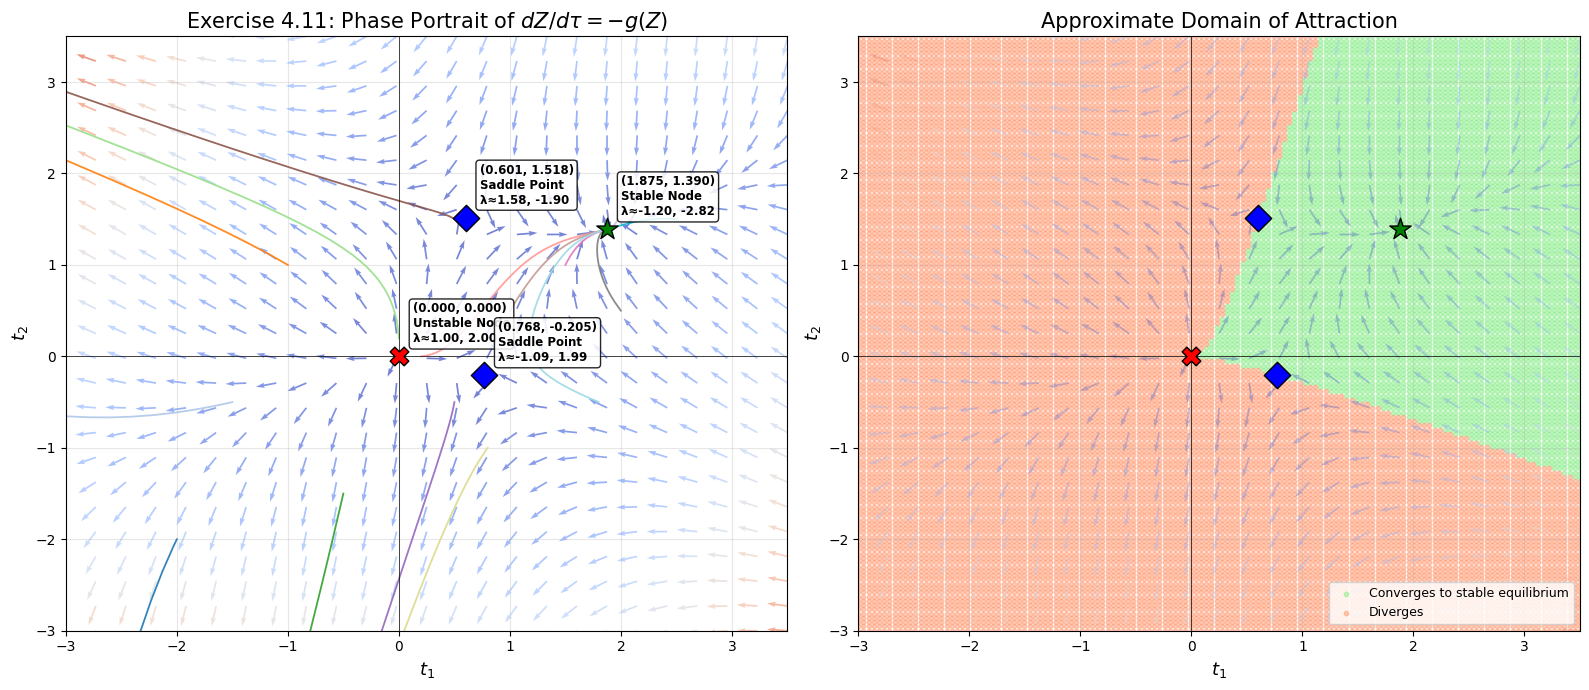

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp

def g(theta):
    t1, t2 = theta
    g1 = t1**2 - t1 - t1*t2 + 0.5*t2**2
    g2 = t2**2 - 2*t2 + t1*t2 - 0.5*t1**2
    return np.array([g1, g2])

def Jg(theta):
    t1, t2 = theta
    return np.array([
        [2*t1 - 1 - t2, -t1 + t2],
        [t2 - t1, 2*t2 - 2 + t1]
    ])

def ode_rhs(tau, z):
    return -g(z)

def classify_equilibrium(eq):
    eigvals = np.linalg.eigvals(-Jg(eq))
    re = np.real(eigvals)
    if np.all(re < -1e-8):
        kind = "Stable Node"
    elif np.all(re > 1e-8):
        kind = "Unstable Node"
    elif np.any(re > 1e-8) and np.any(re < -1e-8):
        kind = "Saddle Point"
    else:
        kind = "Non-hyperbolic / borderline"
    return eigvals, kind

def unique_rows(rows, tol=1e-6):
    uniq = []
    for r in rows:
        if not any(np.linalg.norm(r - u) < tol for u in uniq):
            uniq.append(r)
    return uniq

def find_equilibria():
    guesses_t1 = np.linspace(-3, 6, 41)
    guesses_t2 = np.linspace(-3, 6, 41)
    roots = []
    for t1 in guesses_t1:
        for t2 in guesses_t2:
            root, info, ier, msg = fsolve(g, [t1, t2], full_output=True)
            if ier == 1 and np.linalg.norm(g(root)) < 1e-10 and np.all(np.isfinite(root)):
                roots.append(root)
    roots = unique_rows(roots, tol=1e-5)
    roots = sorted(roots, key=lambda x: (x[0], x[1]))
    return np.array(roots)

equilibria = find_equilibria()

print("Equilibria found:")
for i, eq in enumerate(equilibria, 1):
    eigvals, kind = classify_equilibrium(eq)
    print(f"{i}. theta* = ({eq[0]:.6f}, {eq[1]:.6f})")
    print(f"   ||g(theta*)|| = {np.linalg.norm(g(eq)):.3e}")
    print(f"   eig(-Jg) = {eigvals}")
    print(f"   type = {kind}")
    print()

x_min, x_max = -3.0, 3.5
y_min, y_max = -3.0, 3.5

nx, ny = 25, 25
X, Y = np.meshgrid(np.linspace(x_min, x_max, nx), np.linspace(y_min, y_max, ny))
U = np.zeros_like(X)
V = np.zeros_like(Y)

for i in range(nx):
    for j in range(ny):
        val = ode_rhs(0, np.array([X[j, i], Y[j, i]]))
        U[j, i] = val[0]
        V[j, i] = val[1]

speed = np.sqrt(U**2 + V**2)
Un = U / (speed + 1e-12)
Vn = V / (speed + 1e-12)

stable_eq = None
saddle_eqs = []
unstable_eqs = []

for eq in equilibria:
    eigvals, kind = classify_equilibrium(eq)
    if "Stable" in kind:
        stable_eq = eq
    elif "Saddle" in kind:
        saddle_eqs.append(eq)
    elif "Unstable" in kind:
        unstable_eqs.append(eq)

def terminal_behavior(z0, T=30.0):
    try:
        sol = solve_ivp(
            ode_rhs, [0, T], z0, method="RK45",
            max_step=0.05, rtol=1e-7, atol=1e-9
        )
        zT = sol.y[:, -1]
        if not np.all(np.isfinite(zT)):
            return "diverge", zT
        if np.linalg.norm(zT) > 20:
            return "diverge", zT
        if stable_eq is not None and np.linalg.norm(zT - stable_eq) < 1e-2:
            return "stable", zT
        for eq in equilibria:
            if np.linalg.norm(zT - eq) < 1e-2:
                return "other_eq", zT
        return "other", zT
    except Exception:
        return "diverge", np.array([np.nan, np.nan])

bx = np.linspace(x_min, x_max, 140)
by = np.linspace(y_min, y_max, 140)
BX, BY = np.meshgrid(bx, by)

stable_pts_x, stable_pts_y = [], []
other_pts_x, other_pts_y = [], []
div_pts_x, div_pts_y = [], []

for xx, yy in zip(BX.ravel(), BY.ravel()):
    label, zT = terminal_behavior(np.array([xx, yy]), T=30.0)
    if label == "stable":
        stable_pts_x.append(xx)
        stable_pts_y.append(yy)
    elif label == "diverge":
        div_pts_x.append(xx)
        div_pts_y.append(yy)
    else:
        other_pts_x.append(xx)
        other_pts_y.append(yy)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.quiver(X, Y, Un, Vn, speed, cmap="coolwarm", alpha=0.7, scale=35)

traj_starts = [
    (-2.0, -2.0), (-1.5, -0.5), (-1.0, 1.0), (-0.5, -1.5), (0.0, 0.2),
    (0.2, 0.0), (0.5, -0.5), (0.5, 1.5), (1.0, 0.5), (1.5, 1.0),
    (2.0, 0.5), (2.0, 2.0), (0.8, -1.0), (2.5, 1.5), (1.8, -0.5)
]
colors = plt.cm.tab20(np.linspace(0, 1, len(traj_starts)))

for c, z0 in zip(colors, traj_starts):
    sol = solve_ivp(
        ode_rhs, [0, 30], z0, method="RK45",
        max_step=0.05, rtol=1e-7, atol=1e-9
    )
    ax1.plot(sol.y[0], sol.y[1], color=c, lw=1.3, alpha=0.9)

for eq in equilibria:
    eigvals, kind = classify_equilibrium(eq)
    if "Stable" in kind:
        ax1.scatter(eq[0], eq[1], c="green", marker="*", s=260, edgecolors="k", zorder=5)
        label = f"({eq[0]:.3f}, {eq[1]:.3f})\n{kind}\nλ≈{np.real(eigvals[0]):.2f}, {np.real(eigvals[1]):.2f}"
    elif "Saddle" in kind:
        ax1.scatter(eq[0], eq[1], c="blue", marker="D", s=180, edgecolors="k", zorder=5)
        label = f"({eq[0]:.3f}, {eq[1]:.3f})\n{kind}\nλ≈{np.real(eigvals[0]):.2f}, {np.real(eigvals[1]):.2f}"
    else:
        ax1.scatter(eq[0], eq[1], c="red", marker="X", s=180, edgecolors="k", zorder=5)
        label = f"({eq[0]:.3f}, {eq[1]:.3f})\n{kind}\nλ≈{np.real(eigvals[0]):.2f}, {np.real(eigvals[1]):.2f}"

    ax1.annotate(
        label, (eq[0], eq[1]),
        xytext=(10, 10), textcoords="offset points",
        fontsize=8.5, fontweight="bold",
        bbox=dict(boxstyle="round", fc="white", alpha=0.85)
    )

ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.set_xlabel(r"$t_1$", fontsize=13)
ax1.set_ylabel(r"$t_2$", fontsize=13)
ax1.set_title(r"Exercise 4.11: Phase Portrait of $dZ/d\tau=-g(Z)$", fontsize=15)
ax1.grid(True, alpha=0.3)
ax1.axhline(0, color="k", lw=0.5)
ax1.axvline(0, color="k", lw=0.5)

if stable_pts_x:
    ax2.scatter(stable_pts_x, stable_pts_y, c="lightgreen", s=10, alpha=0.55, label="Converges to stable equilibrium")
if other_pts_x:
    ax2.scatter(other_pts_x, other_pts_y, c="lightgrey", s=10, alpha=0.45, label="Other behavior")
if div_pts_x:
    ax2.scatter(div_pts_x, div_pts_y, c="lightsalmon", s=10, alpha=0.55, label="Diverges")

ax2.quiver(X, Y, Un, Vn, speed, cmap="coolwarm", alpha=0.35, scale=35)

for eq in equilibria:
    eigvals, kind = classify_equilibrium(eq)
    if "Stable" in kind:
        ax2.scatter(eq[0], eq[1], c="green", marker="*", s=260, edgecolors="k", zorder=5)
    elif "Saddle" in kind:
        ax2.scatter(eq[0], eq[1], c="blue", marker="D", s=180, edgecolors="k", zorder=5)
    else:
        ax2.scatter(eq[0], eq[1], c="red", marker="X", s=180, edgecolors="k", zorder=5)

ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.set_xlabel(r"$t_1$", fontsize=13)
ax2.set_ylabel(r"$t_2$", fontsize=13)
ax2.set_title("Approximate Domain of Attraction", fontsize=15)
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color="k", lw=0.5)
ax2.axvline(0, color="k", lw=0.5)
ax2.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("Ex4_11_Phase_Portrait.png", dpi=160, bbox_inches="tight")
plt.show()

In [5]:
import numpy as np

np.random.seed(42)

p = 20
n_reps = 25
n_iter = 1000

# B: 20×20, 1's on diagonal, 0.5's elsewhere
B = 0.5 * np.ones((p, p)) + 0.5 * np.eye(p)
theta_star = np.zeros(p)

def g(theta):
    nonlinear = np.zeros(p)
    nonlinear[:10] = 4.0 * theta[:10]**3
    return nonlinear + 2.0 * B @ theta

def Y(theta, sigma):
    e = np.random.normal(0, sigma, size=p)  # e ~ N(0, σ²I)
    return g(theta) + e

def a_k(k):
    return 0.01 / (k + 101)**0.501

def project(theta):
    return np.clip(theta, -0.1, 0.1)

for sigma in [1, 20]:
    np.random.seed(42)
    terminal_mse_unc = []
    terminal_mse_con = []

    for rep in range(n_reps):
        theta_unc = 0.1 * np.ones(p)
        theta_con = 0.1 * np.ones(p)

        for k in range(n_iter):
            ak = a_k(k)
            theta_unc = theta_unc - ak * Y(theta_unc, sigma)
            theta_con = project(theta_con - ak * Y(theta_con, sigma))

        terminal_mse_unc.append(np.sum((theta_unc - theta_star)**2))
        terminal_mse_con.append(np.sum((theta_con - theta_star)**2))

    avg_mse_unc = np.mean(terminal_mse_unc)
    avg_mse_con = np.mean(terminal_mse_con)
    rms_unc = np.sqrt(avg_mse_unc)
    rms_con = np.sqrt(avg_mse_con)

    print(f"σ = {sigma}:")
    print(f"  Unconstrained RMS = {rms_unc:.6f}")
    print(f"  Constrained   RMS = {rms_con:.6f}")
    print(f"  Ratio (unc/con)   = {rms_unc/rms_con:.2f}")

σ = 1:
  Unconstrained RMS = 0.054337
  Constrained   RMS = 0.050128
  Ratio (unc/con)   = 1.08
σ = 20:
  Unconstrained RMS = 1.041277
  Constrained   RMS = 0.256831
  Ratio (unc/con)   = 4.05
